# `verify_nrt.ipynb` — v2026b method comparison

Compares the two v2026b NRT-extension products against each other:

* `outputs/gml_ff_co2_2026b_assumed.nc` — gas/oil +2.5%, coal/flaring +1% per fuel for the 2025→2026 step (the v2026 default carried forward).
* `outputs/gml_ff_co2_2026b_cm_yearly.nc` — per-country CarbonMonitor Q1-2026/Q1-2025 ratio applied uniformly across all five sectors.

Both methods share the same Feb..Apr 2026 monthly shape (via the `Jan_2026 × CM_monthly_ratio` overwrite). Only the 2025→2026 annual baseline differs.

Companion to `compare_methods.py` (which writes the canonical `outputs/v2026b_method_comparison.{md,png}` artefacts and is the source of truth for the headline numbers — this notebook just loads them and adds a few sanity checks specific to the partial-year extension).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, Markdown, display

OUT_DIR = Path("outputs")
ASSUMED = OUT_DIR / "gml_ff_co2_2026b_assumed.nc"
CM      = OUT_DIR / "gml_ff_co2_2026b_cm_yearly.nc"
MD      = OUT_DIR / "v2026b_method_comparison.md"
PNG     = OUT_DIR / "v2026b_method_comparison.png"

for p in (ASSUMED, CM, MD, PNG):
    assert p.exists(), f"Missing {p} — run ff_country.py + post_process.py for both methods, then python compare_methods.py"

ds_a = xr.open_dataset(ASSUMED)
ds_b = xr.open_dataset(CM)
print(f"assumed   : {ds_a.sizes['time']} months, {str(ds_a.time.values[0])[:10]} .. {str(ds_a.time.values[-1])[:10]}")
print(f"cm_yearly : {ds_b.sizes['time']} months, {str(ds_b.time.values[0])[:10]} .. {str(ds_b.time.values[-1])[:10]}")
print(f"variable  : {list(ds_a.data_vars)}")
print(f"global attrs: title={ds_a.attrs['title']!r}")
print(f"             v2026b_annual_method={ds_a.attrs.get('v2026b_annual_method')!r} / {ds_b.attrs.get('v2026b_annual_method')!r}")

assumed   : 400 months, 1993-01-15 .. 2026-04-15
cm_yearly : 400 months, 1993-01-15 .. 2026-04-15
variable  : ['fossil_imp', 'fossil_imp_cell', 'cell_areas', 'year_lengths', 'month_lengths', 'earth_radius', 'time_bnds']
global attrs: title='Miller-Pera Fossil Fuel CO2 prior estimates for CarbonTracker'
             v2026b_annual_method='assumed' / 'cm_yearly'


## Headline summary (rendered from `compare_methods.py`)


In [2]:
display(Markdown(MD.read_text()))

# v2026b — Method comparison: `assumed` vs `cm_yearly`

Two annual baselines for the 2025 → 2026 step:

* **assumed**: gas/oil +2.5%, coal/flaring +1% (per-fuel; same as 2025)
* **cm_yearly**: per-country CM Q1-2026/Q1-2025 ratio applied uniformly across fuels

Both methods produce the same Feb..Apr 2026 monthly shape (via `Jan_2026 × CM_monthly_ratio` overwrite).

## Annual totals (PgC) — last 6 years

| Year | assumed | cm_yearly | Δ (PgC) | Δ (%) |
|------|---------|-----------|---------|-------|
| 2020 | 9.5902 | 9.5902 | +0.0000 | +0.00% |
| 2021 | 10.0053 | 10.0053 | -0.0000 | -0.00% |
| 2022 | 10.2812 | 10.2812 | +0.0000 | +0.00% |
| 2023 | 10.3907 | 10.3907 | -0.0000 | -0.00% |
| 2024 | 10.5733 | 10.5734 | +0.0001 | +0.00% |
| 2025 | 10.7467 | 10.7463 | -0.0004 | -0.00% |
| 2026 *(partial Jan..Apr)* | 3.7416 | 3.7404 | -0.0011 | -0.03% |

## Per-month 2026 (partial year)

| Month | assumed | cm_yearly | Δ (PgC) | Δ (%) |
|-------|---------|-----------|---------|-------|
| 2026-01 | 1.0366 | 1.0316 | -0.0049 | -0.47% |
| 2026-02 | 0.8692 | 0.8704 | +0.0012 | +0.14% |
| 2026-03 | 0.9518 | 0.9531 | +0.0014 | +0.14% |
| 2026-04 | 0.8841 | 0.8853 | +0.0012 | +0.14% |

## Spatial RMS difference per month (last 16 months)

| Month | RMS (mol m⁻² s⁻¹) | rel-RMS (%) |
|-------|---------------------|-------------|
| 2025-01 | 1.193e-09 | 0.24% |
| 2025-02 | 1.307e-09 | 0.28% |
| 2025-03 | 1.285e-09 | 0.29% |
| 2025-04 | 1.154e-09 | 0.27% |
| 2025-05 | 9.132e-10 | 0.23% |
| 2025-06 | 6.405e-10 | 0.17% |
| 2025-07 | 3.375e-10 | 0.10% |
| 2025-08 | 2.236e-11 | 0.01% |
| 2025-09 | 5.313e-10 | 0.13% |
| 2025-10 | 1.227e-09 | 0.29% |
| 2025-11 | 2.154e-09 | 0.47% |
| 2025-12 | 3.294e-09 | 0.68% |
| 2026-01 | 4.535e-09 | 0.92% |
| 2026-02 | 1.220e-09 | 0.27% |
| 2026-03 | 1.247e-09 | 0.28% |
| 2026-04 | 1.108e-09 | 0.26% |


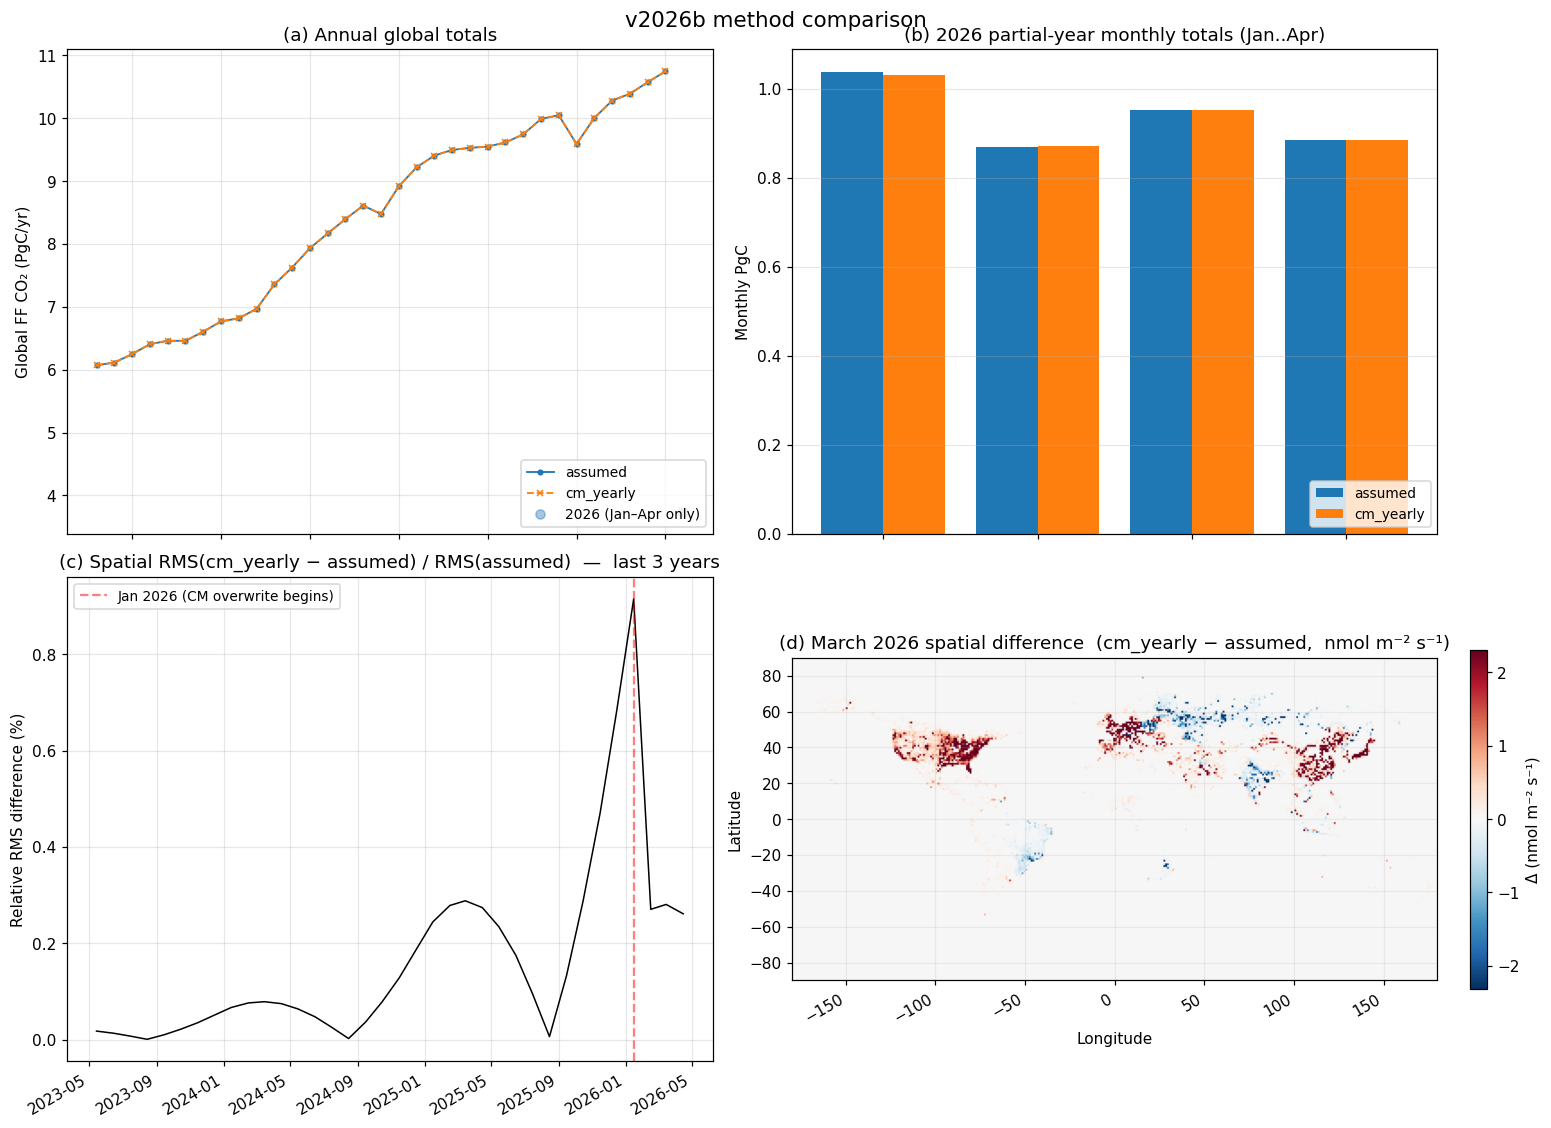

In [3]:
display(Image(filename=str(PNG)))

## Check 12a — partial-year structure

Both NetCDFs should end at 2026-04-15 with 400 months total (33 full years × 12 + 4 partial). The same time axis applies to both.

In [4]:
from collections import Counter

n_months = ds_a.sizes["time"]
assert n_months == 400, f"Expected 400 months, got {n_months}"
assert ds_b.sizes["time"] == 400

times = pd.DatetimeIndex(ds_a.time.values)
assert times[-1].year == 2026 and times[-1].month == 4, f"Last month should be 2026-04, got {times[-1]}"

year_counts = Counter(times.year)
assert year_counts[2025] == 12, f"2025 should have 12 months, got {year_counts[2025]}"
assert year_counts[2026] == 4, f"2026 should have 4 months, got {year_counts[2026]}"
print("PASS: 33 full years (1993-2025) + 4 partial months (2026-01..2026-04) on both NetCDFs")

PASS: 33 full years (1993-2025) + 4 partial months (2026-01..2026-04) on both NetCDFs


## Check 12b — CM monthly overwrite was applied to Feb/Mar 2026

The pipeline overwrites Feb..Apr 2026 with `prior_year_same_month × CM_YoY_ratio[country]`, with WORLD YoY for ocean / bunker cells. We verify by re-deriving an expected ratio from the WORLD column of `processed_inputs/CM_monthly_yoy_ratios_2026.csv` and checking ocean cells against `Feb_2025 × WORLD_YoY`.

April 2026 is **not** overwritten (CM hasn't published April yet at the time of this run); those April cells should equal whatever the spline + seasonal cycle produced.

In [5]:
cm_yoy = pd.read_csv("processed_inputs/CM_monthly_yoy_ratios_2026.csv", index_col=0)
world_yoy = {c: cm_yoy.at["WORLD", c] for c in cm_yoy.columns
             if c.startswith("2026-") and c != "2026-01"}
print("WORLD CM YoY ratios (Feb/Feb-prior, Mar/Mar-prior, etc.):")
for c, r in world_yoy.items():
    if pd.notna(r):
        print(f"  {c}: {r:.4f}")
    else:
        print(f"  {c}: NaN — month not in CM 2026 data")

# Mid-Atlantic at ~30°N, 40°W is reliable shipping ocean (no NAM/Eurasian seasonality applied).
lat_idx = int(np.argmin(np.abs(ds_a.lat.values - 30.0)))
lon_idx = int(np.argmin(np.abs(ds_a.lon.values - (-40.0))))

for method_name, ds in (("assumed", ds_a), ("cm_yearly", ds_b)):
    fi = ds["fossil_imp"].values  # (time, lat, lon)
    base_idx_2026 = (2026 - 1993) * 12
    base_idx_2025 = (2025 - 1993) * 12
    print(f"\n  [{method_name}] mid-Atlantic ocean cell (~30°N, 40°W):")
    for offset, period in enumerate(["2026-02", "2026-03", "2026-04"], start=1):
        prior_val = fi[base_idx_2025 + offset, lat_idx, lon_idx]
        actual    = fi[base_idx_2026 + offset, lat_idx, lon_idx]
        ratio = world_yoy.get(period)
        if ratio is not None and pd.notna(ratio):
            expected = prior_val * ratio
            rel_err = abs(actual - expected) / max(abs(expected), 1e-30)
            ok = "PASS" if rel_err < 1e-6 else f"FAIL (rel err {rel_err:.2e})"
            print(f"    {period} actual={actual:.3e}  "
                  f"prior_year={prior_val:.3e} × YoY={ratio:.4f} "
                  f"= {expected:.3e}  {ok}")
        else:
            print(f"    {period} actual={actual:.3e}  (no CM ratio — left untouched)")

WORLD CM YoY ratios (Feb/Feb-prior, Mar/Mar-prior, etc.):
  2026-02: 0.9776
  2026-03: 1.0042
  2026-04: 1.0058

  [assumed] mid-Atlantic ocean cell (~30°N, 40°W):
    2026-02 actual=2.394e-10  prior_year=2.449e-10 × YoY=0.9776 = 2.394e-10  PASS
    2026-03 actual=2.462e-10  prior_year=2.452e-10 × YoY=1.0042 = 2.462e-10  PASS
    2026-04 actual=2.470e-10  prior_year=2.455e-10 × YoY=1.0058 = 2.470e-10  PASS

  [cm_yearly] mid-Atlantic ocean cell (~30°N, 40°W):
    2026-02 actual=2.402e-10  prior_year=2.457e-10 × YoY=0.9776 = 2.402e-10  PASS
    2026-03 actual=2.471e-10  prior_year=2.461e-10 × YoY=1.0042 = 2.471e-10  PASS
    2026-04 actual=2.478e-10  prior_year=2.464e-10 × YoY=1.0058 = 2.478e-10  PASS


## Check 12c — methods agree exactly through 2024 (no extrapolation)

1993-2024 in both files comes straight from CDIAC (1993-2022) + EI ratios (2023-2024). No method-dependent code touches these years; they should be byte-identical to within float64 precision.

In [6]:
fa = ds_a["fossil_imp"].values
fb = ds_b["fossil_imp"].values

# Months 0..(2024-1993+1)*12 = 0..384 are 1993-01..2024-12
n_pre = (2024 - 1993 + 1) * 12  # 384

def diff_summary(label: str, slc: slice) -> tuple[float, float, float]:
    """Return (max abs diff, RMS abs diff, 99th-pct abs diff)."""
    a, b = fa[slc], fb[slc]
    abs_diff = np.abs(b - a)
    max_a   = abs_diff.max()
    rms_a   = float(np.sqrt(np.mean(abs_diff ** 2)))
    p99_a   = float(np.percentile(abs_diff, 99))
    rms_ref = float(np.sqrt(np.mean(a ** 2)))
    rel_rms = rms_a / rms_ref if rms_ref > 0 else 0.0
    print(f"  {label:24s}  max |Δ| = {max_a:.3e}   RMS |Δ| = {rms_a:.3e}   "
          f"p99 |Δ| = {p99_a:.3e}   rel-RMS = {100*rel_rms:.3f}%")
    return max_a, rms_a, rel_rms

# PIQS is a global tridiagonal spline — changing the 2026 boundary propagates
# back through the solve, so 1993-2024 isn't byte-identical between methods.
# The propagation is bounded; we expect rel-RMS < ~1% for pre-2026 years and
# the divergence to concentrate in 2026 itself.
_,  _, rel_pre  = diff_summary("1993-2024 (n=384 months)", slice(0, n_pre))
_,  _, rel_2025 = diff_summary("2025      (n=12 months) ", slice(n_pre, n_pre + 12))
abs_2026, _, rel_2026 = diff_summary("2026 Q1   (n=4 months)  ", slice(n_pre + 12, None))

# Sanity: spline-propagation noise stays well under 1%, and the 2026 divergence
# is at least an order of magnitude larger than the pre-2026 noise.
assert rel_pre  < 0.01, f"1993-2024 rel-RMS should be < 1%, got {rel_pre:.2%}"
assert rel_2025 < 0.01, f"2025 rel-RMS should be < 1%, got {rel_2025:.2%}"
assert rel_2026 > rel_pre * 5, (
    f"2026 divergence ({rel_2026:.2%}) should be >> pre-2026 spline noise "
    f"({rel_pre:.2%})"
)
print("\nPASS: pre-2026 differences are bounded spline-propagation noise; "
      "2026 diverges as expected (>5× larger than pre-2026).")

  1993-2024 (n=384 months)  max |Δ| = 1.020e-07   RMS |Δ| = 7.045e-11   p99 |Δ| = 1.788e-12   rel-RMS = 0.021%
  2025      (n=12 months)   max |Δ| = 3.817e-07   RMS |Δ| = 1.436e-09   p99 |Δ| = 1.882e-09   rel-RMS = 0.338%
  2026 Q1   (n=4 months)    max |Δ| = 5.266e-07   RMS |Δ| = 2.492e-09   p99 |Δ| = 3.245e-09   rel-RMS = 0.548%

PASS: pre-2026 differences are bounded spline-propagation noise; 2026 diverges as expected (>5× larger than pre-2026).
